In [37]:
!pip install folium geopy osmnx networkx
!pip install folium geopy geopandas osmnx networkx scikit-learn matplotlib
!pip install scikit-learn numpy


In [19]:
import folium
map = folium.Map(location=[10.770690727482762, 106.6699549807265], zoom_start=13)
locations = [("Vạn Hạnh Mall", 10.770690727482762, 106.6699549807265),("Trường ĐH Kinh Tế", 10.761116430356939, 106.66831507887927),("DOL Đình ", 10.769037188801708, 106.66806980956174)]
for name, lat, lon in locations:
    folium.Marker(location=[lat, lon],popup=name).add_to(map)
map

In [21]:
from geopy.distance import geodesic
center = (21.0285, 105.8542)
for name, lat, lon in locations:
    dist = geodesic(center, (lat, lon)).km
    print(name, ":", round(dist, 2), "km")

Vạn Hạnh Mall : 1138.48 km
Trường ĐH Kinh Tế : 1139.52 km
DOL Đình  : 1138.64 km


In [23]:
!pip install folium
import folium
from folium.plugins import HeatMap
data = [[10.7709,106.6696],[10.7723,106.6602],[10.7639,106.6705], [10.7798,106.6653]]
map = folium.Map(location=[10.7720,106.6670], zoom_start=15)
HeatMap(data).add_to(map)
map

In [26]:
import pandas as pd
data = {"phuong": ["Phường 1", "Phường 2", "Phường 3", "Phường 4", "Phường 5"],"dan_so": [20000, 18000, 22000, 15000, 17000]}
df = pd.DataFrame(data)
df.to_csv("quan10_data.csv", index=False)
df
df = pd.read_csv("quan10_data.csv")
print(df)

     phuong  dan_so
0  Phường 1   20000
1  Phường 2   18000
2  Phường 3   22000
3  Phường 4   15000
4  Phường 5   17000


In [28]:
map = folium.Map(location=[10.7720, 106.6670], zoom_start=13)
folium.Circle(location=[10.7720, 106.6670],radius=3000,color='blue',fill=True).add_to(map)
map

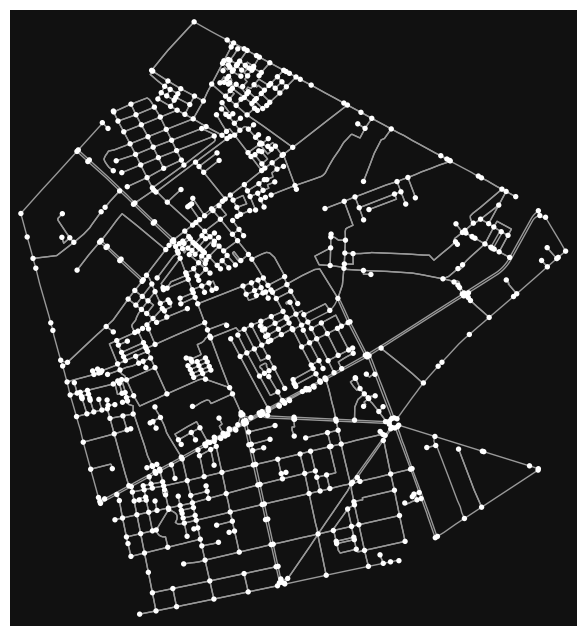

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [29]:
import osmnx as ox
G = ox.graph_from_place("District 10, Ho Chi Minh City, Vietnam", network_type='drive')
ox.plot_graph(G)

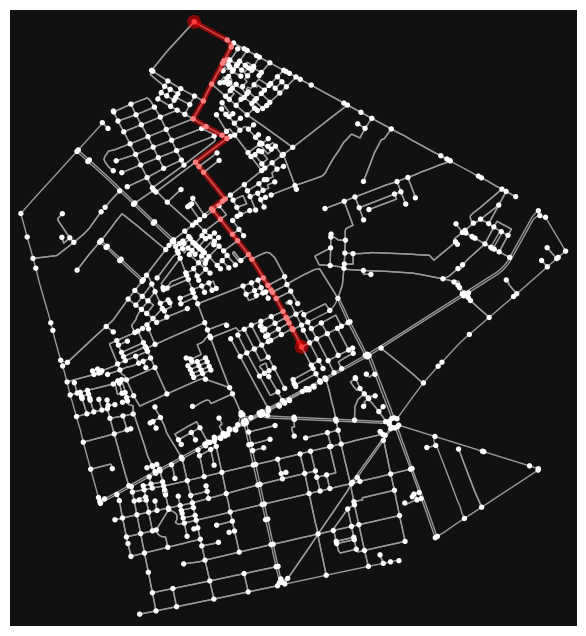

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [42]:
import osmnx as ox
import networkx as nx
G = ox.graph_from_place("District 10, Ho Chi Minh City, Vietnam", network_type='drive')
orig = ox.distance.nearest_nodes(G, 10.76117967131381, 106.66836872305572)
dest = ox.distance.nearest_nodes(G, 106.6696, 10.7709)
route = nx.shortest_path(G, orig, dest, weight='length')
ox.plot_graph_route(G, route)

In [41]:
import folium
import numpy as np
from scipy.spatial.distance import cdist
center = [10.7720, 106.6670]
drivers = np.array([[10.7723, 106.6602],  [10.7709, 106.6696],  [10.7798, 106.6653]   ])
customers = np.array([[10.7639, 106.6705], [10.7722, 106.6675]  ])
dist_matrix = cdist(customers, drivers)
assignments = np.argmin(dist_matrix, axis=1)
map = folium.Map(location=center, zoom_start=15)
for i, (lat, lon) in enumerate(drivers):
    folium.Marker([lat, lon],popup=f"Tài xế {i}",icon=folium.Icon(color="blue")).add_to(map)
for i, (lat, lon) in enumerate(customers):
    folium.Marker([lat, lon],popup=f"Khách {i}",icon=folium.Icon(color="red")).add_to(map)
for i, cust in enumerate(customers):
    driver = drivers[assignments[i]]
    folium.PolyLine(locations=[cust, driver],color="green").add_to(map)
map

In [43]:
import folium
import numpy as np
from sklearn.cluster import KMeans
center = [10.7720, 106.6670]
data = np.array([[10.7709,106.6696],  [10.7639,106.6705],  [10.7798,106.6653],  [10.7740,106.6680],[10.7680,106.6660]])
kmeans = KMeans(n_clusters=2, random_state=0).fit(data)
labels = kmeans.labels_
centers = kmeans.cluster_centers_
map = folium.Map(location=center, zoom_start=15)
colors = ["red", "blue"]
for i, (lat, lon) in enumerate(data):
    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        color=colors[labels[i]],
        fill=True,
        fill_color=colors[labels[i]],
        popup=f"Cluster {labels[i]}"
    ).add_to(map)

for i, (lat, lon) in enumerate(centers):
    folium.Marker(
        location=[lat, lon],
        popup=f"Center {i}",
        icon=folium.Icon(color="green", icon="star")
    ).add_to(map)

map

In [44]:
import folium
import numpy as np
from sklearn.linear_model import LinearRegression
center = [10.7720, 106.6670]
X = np.array([[6],[8],[10],[12],[16],[18],[20]])
y = np.array([20, 80, 50, 40, 70, 90, 60])
model = LinearRegression().fit(X, y)
pred = model.predict([[17]])[0]
print("Mức độ tắc nghẽn lúc 17h:", pred)

locations = [
    ("Vạn Hạnh Mall", 10.7709,106.6696),
    ("BV Nhi Đồng 1", 10.7639,106.6705),
    ("Công viên", 10.7798,106.6653)]
map = folium.Map(location=center, zoom_start=15)
def get_color(value):
    if value < 40:
        return "green"
    elif value < 70:
        return "orange"
    else:
        return "red"
for name, lat, lon in locations:
    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        color=get_color(pred),
        fill=True,
        fill_color=get_color(pred),
        popup=f"{name} - Tắc nghẽn: {round(pred,1)}").add_to(map)

map

Mức độ tắc nghẽn lúc 17h: 68.71575342465754


In [45]:
import folium
import numpy as np
from sklearn.linear_model import LinearRegression
center = [10.7720, 106.6670]
X = np.array([[6],[8],[10],[12],[16],[18],[20]])
y = np.array([10, 50, 30, 20, 60, 80, 40])
model = LinearRegression().fit(X, y)
pred = model.predict([[19]])[0]
print("Nhu cầu lúc 19h:", pred)
locations = [
    ("Vạn Hạnh Mall", 10.7709,106.6696),
    ("BV Nhi Đồng 1", 10.7639,106.6705),
    ("Công viên Lê Thị Riêng", 10.7798,106.6653)
]
map = folium.Map(location=center, zoom_start=15)
def get_color(value):
    if value < 30:
        return "green"
    elif value < 60:
        return "orange"
    else:
        return "red"
for name, lat, lon in locations:
    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        color=get_color(pred),
        fill=True,
        fill_color=get_color(pred),
        popup=f"{name} - Nhu cầu: {round(pred,1)}"
    ).add_to(map)

map

Nhu cầu lúc 19h: 58.784246575342465


In [46]:
import folium
import numpy as np
from itertools import permutations
center = [10.7720, 106.6670]
points = [
    ("Điểm A", 10.7709,106.6696),
    ("Điểm C", 10.7639,106.6705),
    ("Điểm D", 10.7798,106.6653)
]

coords = [(lat, lon) for _, lat, lon in points]
def total_distance(route):
    dist = 0
    for i in range(len(route)-1):
        a = np.array(route[i])
        b = np.array(route[i+1])
        dist += np.linalg.norm(a - b)
    return dist
best_route = None
min_dist = float("inf")

for perm in permutations(coords):
    dist = total_distance(perm)
    if dist < min_dist:
        min_dist = dist
        best_route = perm
print("Tuyến tối ưu:", best_route)
print("Khoảng cách:", min_dist)
map = folium.Map(location=center, zoom_start=15)
for name, lat, lon in points:
    folium.Marker(
        [lat, lon],
        popup=name,
        icon=folium.Icon(color="blue")
    ).add_to(map)
folium.PolyLine(
    locations=best_route,
    color="red",
    weight=5
).add_to(map)
map

Tuyến tối ưu: ((10.7639, 106.6705), (10.7709, 106.6696), (10.7798, 106.6653))
Khoảng cách: 0.016941951029959462


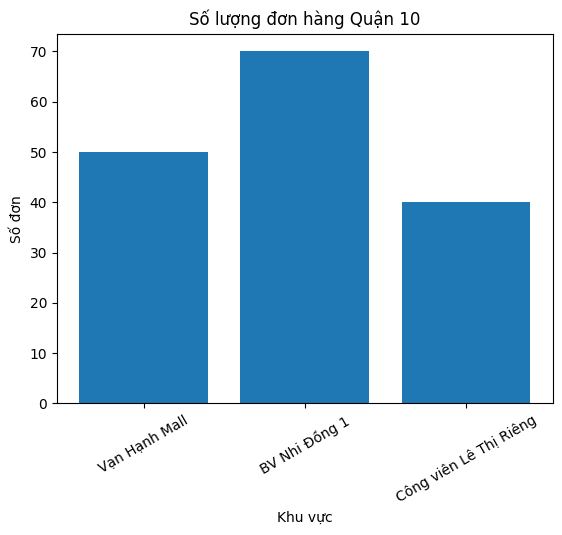

In [47]:
import folium
import matplotlib.pyplot as plt
locations = [
    ("Vạn Hạnh Mall", 10.7709,106.6696, 50),
    ("BV Nhi Đồng 1", 10.7639,106.6705, 70),
    ("Công viên Lê Thị Riêng", 10.7798,106.6653, 40)
]
names = [x[0] for x in locations]
orders = [x[3] for x in locations]

plt.figure()
plt.bar(names, orders)
plt.xticks(rotation=30)
plt.title("Số lượng đơn hàng Quận 10")
plt.xlabel("Khu vực")
plt.ylabel("Số đơn")
plt.show()
center = [10.7720, 106.6670]
map = folium.Map(location=center, zoom_start=15)
def get_color(value):
    if value < 40:
        return "green"
    elif value < 60:
        return "orange"
    else:
        return "red"
for name, lat, lon, value in locations:
    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        color=get_color(value),
        fill=True,
        fill_color=get_color(value),
        popup=f"{name}: {value} đơn"
    ).add_to(map)

map

In [48]:
import folium
import time
center = [10.7720, 106.6670]
route = [
    (10.7709,106.6696),
    (10.7639,106.6705),
    (10.7798,106.6653)
]

map = folium.Map(location=center, zoom_start=15)
folium.PolyLine(route, color="blue", weight=5).add_to(map)
for i, point in enumerate(route):
    folium.Marker(
        location=point,
        popup=f"Xe tại điểm {i}",
        icon=folium.Icon(color="red", icon="car")
    ).add_to(map)
map

In [50]:
import folium
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression
center = [10.7720, 106.6670]
X = np.array([[6],[8],[10],[12],[16],[18],[20]])
y = np.array([10, 50, 30, 20, 60, 80, 40])
model = LinearRegression().fit(X, y)
demand_pred = model.predict([[19]])[0]
drivers = np.array([
    [10.7723,106.6602],
    [10.7709,106.6696],
    [10.7798,106.6653]
])

customers = np.array([
    [10.7639,106.6705]
])
dist = cdist(customers, drivers)
driver_idx = np.argmin(dist)
map = folium.Map(location=center, zoom_start=15)
for i, (lat, lon) in enumerate(drivers):
    folium.Marker(
        [lat, lon],
        popup=f"Tài xế {i}",
        icon=folium.Icon(color="blue")
    ).add_to(map)
for i, (lat, lon) in enumerate(customers):
    folium.Marker(
        [lat, lon],
        popup=f"Khách (Nhu cầu: {round(demand_pred,1)})",
        icon=folium.Icon(color="red")
    ).add_to(map)
best_driver = drivers[driver_idx]
folium.PolyLine(
    locations=[customers[0], best_driver],
    color="green",
    weight=5
).add_to(map)

map